# Aula Semana 04: CRISP-DM Fases 4 & 5 — Modelagem com Random Forest e Avaliação de ROI Financeiro

## 1. Visão Geral & Objetivos de Aprendizagem
Nesta aula, avançaremos para as **Fases 4 (Modeling)** e **5 (Evaluation)** do ciclo CRISP-DM utilizando o dataset oficial de risco de crédito (`CRISP_DM_Random_Forest_Credito.ipynb`), localizado na pasta [`materiais/`](../materiais/CRISP_DM_Random_Forest_Credito.ipynb).

Ao final deste material, você será capaz de:
- Compreender a arquitetura do algoritmo **Random Forest** (Floresta Aleatória) e por que ele é ideal para dados ruidosos e desbalanceados.
- Treinar o classificador Random Forest configurando os parâmetros de **Bagging** e **peso de classes** (`class_weight='balanced'`).
- Avaliar o desempenho estatístico do modelo através do `classification_report`, Matriz de Confusão e a métrica de **ROC-AUC**.
- Extrair e interpretar a **Importância dos Atributos (Feature Importance)** para validar se o modelo eliminou o ruído do dataset.
- Calcular o **Retorno Financeiro sobre o Investimento (ROI)** e a economia líquida gerada pelo modelo para a Fintech.

---

## 2. CRISP-DM Fase 4 — Modelagem Preditiva com Random Forest

O **Random Forest** é um método de aprendizado por conjunto (*Ensemble Learning*) baseado no algoritmo de **Bagging** (*Bootstrap Aggregating*).

![Random Forest e Feature Importance](images/random_forest_feature_importance_pt.jpg)

### Por que o Random Forest é ideal para a nossa base de crédito?

1. **Bagging & Bootstrap**: Combina centenas de árvores de decisão independentes. Cada árvore é treinada em uma amostragem aleatória com reposição dos dados originais. O ruído pontual de uma árvore é anulado pelo voto da maioria.
2. **Amostragem Aleatória de Atributos (`max_features`)**: Em cada divisão de nó (*split*), o algoritmo escolhe apenas um subconjunto sorteado de colunas. Isso impede que variáveis ruidosas monopolizem todas as decisões.
3. **Tratamento do Desbalanceamento (`class_weight='balanced'`)**: O parâmetro ajusta automaticamente os pesos das classes inversamente proporcionais às suas frequências. Isso penaliza severamente a perda de um cliente caloteiro, forçando o modelo a focar no **Recall**.

$$\text{Peso da Classe } c = \frac{n\_amostras}{n\_classes \times n\_amostras\_classe\_c}$$


In [1]:
# =============================================================================
# FASE 4 - MODELING
# Random Forest
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

sns.set_theme(style="whitegrid")


# =============================================================================
# 4.1 - CARREGAMENTO DOS DADOS PREPARADOS
# =============================================================================

print("=" * 70)
print("FASE 4 - MODELING | RANDOM FOREST")
print("=" * 70)

print("\n[4.1] CARREGANDO OS DATASETS PREPARADOS NA AULA ANTERIOR")
print("-" * 70)

X_train = pd.read_csv('../materiais/CRISP_DM_Random_Forest_Credito/X_train.csv')
X_test = pd.read_csv('../materiais/CRISP_DM_Random_Forest_Credito/X_test.csv')
y_train = pd.read_csv('../materiais/CRISP_DM_Random_Forest_Credito/y_train.csv').squeeze()
y_test = pd.read_csv('../materiais/CRISP_DM_Random_Forest_Credito/y_test.csv').squeeze()

print("[OK] Datasets carregados com sucesso!")

print("\nDimensões dos dados:")
print(f"   • X_train: {X_train.shape}")
print(f"   • X_test : {X_test.shape}")
print(f"   • y_train: {y_train.shape}")
print(f"   • y_test : {y_test.shape}")


# =============================================================================
# 4.2 - CONFIGURAÇÃO DO MODELO
# =============================================================================

print("\n[4.2] CONFIGURAÇÃO DO RANDOM FOREST")
print("-" * 70)

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

print("Modelo configurado:")
print(f"   • Número de árvores       : {modelo_rf.n_estimators}")
print(f"   • Profundidade máxima     : {modelo_rf.max_depth}")
print(f"   • Balanceamento de classes: {modelo_rf.class_weight}")
print(f"   • Random State             : {modelo_rf.random_state}")


# =============================================================================
# 4.3 - TREINAMENTO
# =============================================================================

print("\n[4.3] TREINAMENTO DO MODELO")
print("-" * 70)

print("Iniciando treinamento...")
print("O Random Forest está aprendendo padrões a partir dos dados de treino.")

modelo_rf.fit(X_train, y_train)

print("\n[OK] Modelo Random Forest treinado com sucesso!")
print(f"   • Árvores construídas: {len(modelo_rf.estimators_)}")

print("\n" + "=" * 70)
print("FASE 4 - MODELING | TREINAMENTO CONCLUÍDO")
print("=" * 70)

FASE 4 - MODELING | RANDOM FOREST

[4.1] CARREGANDO OS DATASETS PREPARADOS NA AULA ANTERIOR
----------------------------------------------------------------------
[OK] Datasets carregados com sucesso!

Dimensões dos dados:
   • X_train: (2250, 19)
   • X_test : (750, 19)
   • y_train: (2250,)
   • y_test : (750,)

[4.2] CONFIGURAÇÃO DO RANDOM FOREST
----------------------------------------------------------------------
Modelo configurado:
   • Número de árvores       : 200
   • Profundidade máxima     : 10
   • Balanceamento de classes: balanced
   • Random State             : 42

[4.3] TREINAMENTO DO MODELO
----------------------------------------------------------------------
Iniciando treinamento...
O Random Forest está aprendendo padrões a partir dos dados de treino.

[OK] Modelo Random Forest treinado com sucesso!
   • Árvores construídas: 200

FASE 4 - MODELING | TREINAMENTO CONCLUÍDO


---
## 3. CRISP-DM Fase 5 — Avaliação Técnica do Modelo e Impacto Financeiro (ROI)

Nesta fase, avaliamos o modelo em três perspectivas complementares:
1. **Métricas Estatísticas de Classificação**: Análise de Recall, Precision, F1-Score e Curva ROC.
2. **Auditoria de Feature Importance**: Garantir que as variáveis de ruído puro (`ruido_estocastico`, `numero_da_sorte_app`) receberam peso próximo de zero.
3. **Cálculo da Economia Líquida Gerada (ROI)**: Tradução dos resultados em Reais (R$) para o caixa da Fintech.


       RELATÓRIO DE AVALIAÇÃO DO MODELO NO TESTE (FASE 5) 
                  precision    recall  f1-score   support

  Adimplente (0)       0.80      0.75      0.77       439
Inadimplente (1)       0.67      0.73      0.70       311

        accuracy                           0.74       750
       macro avg       0.74      0.74      0.74       750
    weighted avg       0.75      0.74      0.74       750

Área Sob a Curva ROC (ROC-AUC): 0.8364


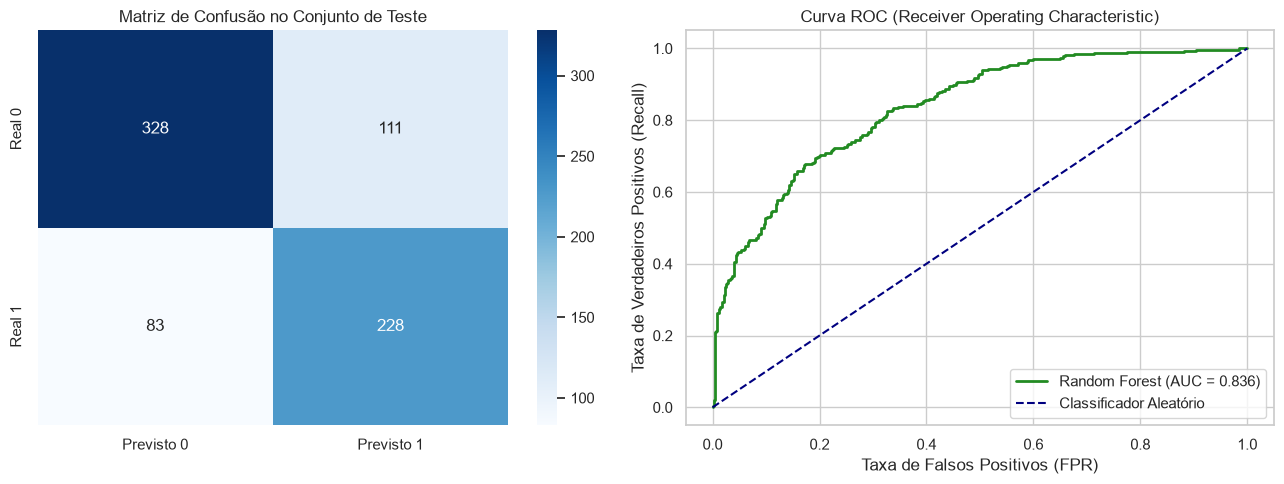

In [2]:
# Avaliação de Métricas Preditivas e Curva ROC (Fase 5.1)
y_pred = modelo_rf.predict(X_test)
y_prob = modelo_rf.predict_proba(X_test)[:, 1]

print("==========================================================")
print("       RELATÓRIO DE AVALIAÇÃO DO MODELO NO TESTE (FASE 5) ")
print("==========================================================")
print(classification_report(y_test, y_pred, target_names=['Adimplente (0)', 'Inadimplente (1)']))

auc_val = roc_auc_score(y_test, y_prob)
print(f"Área Sob a Curva ROC (ROC-AUC): {auc_val:.4f}")

# Gráfico da Matriz de Confusão e Curva ROC
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['Previsto 0', 'Previsto 1'], yticklabels=['Real 0', 'Real 1'])
axes[0].set_title('Matriz de Confusão no Conjunto de Teste')

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='forestgreen', lw=2, label=f'Random Forest (AUC = {auc_val:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Classificador Aleatório')
axes[1].set_title('Curva ROC (Receiver Operating Characteristic)')
axes[1].set_xlabel('Taxa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Taxa de Verdadeiros Positivos (Recall)')
axes[1].legend()

plt.tight_layout()
plt.show()


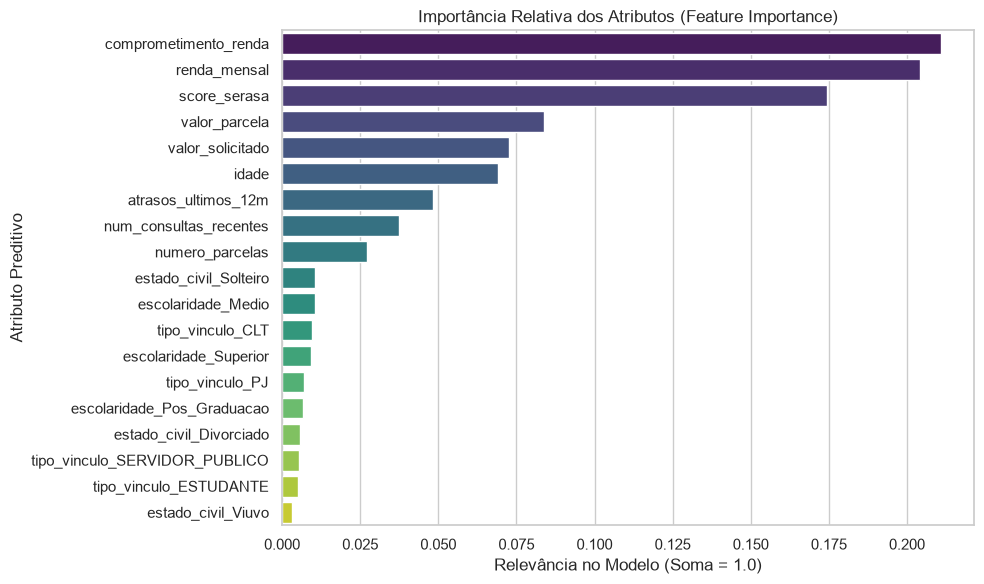

Top 5 Atributos Mais Importantes:
             Atributo  Importância
comprometimento_renda     0.210900
         renda_mensal     0.204093
         score_serasa     0.174340
        valor_parcela     0.083737
     valor_solicitado     0.072711

Posição das Variáveis de Ruído Puro:
Empty DataFrame
Columns: [Atributo, Importância]
Index: []


In [6]:
# Extração e Visualização de Feature Importance (Fase 5.2)
importancia_df = pd.DataFrame({
    'Atributo': X_train.columns,
    'Importância': modelo_rf.feature_importances_
}).sort_values(by='Importância', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importancia_df, x='Importância', y='Atributo', hue='Atributo', palette='viridis')
plt.title('Importância Relativa dos Atributos (Feature Importance)')
plt.xlabel('Relevância no Modelo (Soma = 1.0)')
plt.ylabel('Atributo Preditivo')
plt.tight_layout()
plt.show()

print("Top 5 Atributos Mais Importantes:")
print(importancia_df.head(5).to_string(index=False))

print("\nPosição das Variáveis de Ruído Puro:")
print(importancia_df[importancia_df['Atributo'].isin(['ruido_estocastico', 'numero_da_sorte_app'])].to_string(index=False))


In [4]:
# Cálculo do Retorno Sobre o Investimento - ROI Financeiro (Fase 5.3)
vn, fp, fn, vp = confusion_matrix(y_test, y_pred).ravel()

# Regra de Negócio:
# Falso Negativo (Calote não detectado): Perda de R$ 10.000,00
# Falso Positivo (Bom pagador recusado): Perda de oportunidade de juros de R$ 600,00

total_inadimplentes_teste = fn + vp
custo_sem_modelo = total_inadimplentes_teste * 10000.0  # Todos os calotes seriam aprovados na aprovação cega
custo_com_modelo = (fn * 10000.0) + (fp * 600.0)
economia_liquida = custo_sem_modelo - custo_com_modelo

print("==========================================================")
print("        DEMONSTRATIVO DE RETORNO FINANCEIRO DO PROJETO    ")
print("==========================================================")
print(f"Total de Propostas de Teste Avaliadas: {len(y_test)}")
print(f"Total de Calotes Reais na Amostra:     {total_inadimplentes_teste}")
print(f"Calotes Bloqueados Pelo Modelo (VP):   {vp} ({vp/total_inadimplentes_teste*100:.1f}%)")
print(f"Calotes Não Previstos (FN):            {fn}")
print(f"Bons Pagadores Recusados (FP):         {fp}")
print("----------------------------------------------------------")
print(f"Prejuízo Estimado Sem Modelo:         R$ {custo_sem_modelo:,.2f}")
print(f"Custo Operacional Com Modelo:          R$ {custo_com_modelo:,.2f}")
print("----------------------------------------------------------")
print(f"ECONOMIA LÍQUIDA GERADA PELO MODELO:  R$ {economia_liquida:,.2f}")
print("==========================================================")


        DEMONSTRATIVO DE RETORNO FINANCEIRO DO PROJETO    
Total de Propostas de Teste Avaliadas: 750
Total de Calotes Reais na Amostra:     311
Calotes Bloqueados Pelo Modelo (VP):   228 (73.3%)
Calotes Não Previstos (FN):            83
Bons Pagadores Recusados (FP):         111
----------------------------------------------------------
Prejuízo Estimado Sem Modelo:         R$ 3,110,000.00
Custo Operacional Com Modelo:          R$ 896,600.00
----------------------------------------------------------
ECONOMIA LÍQUIDA GERADA PELO MODELO:  R$ 2,213,400.00


---
## 4. Exercícios de Fixação & Estudo Dirigido

1. Por que o parâmetro `class_weight='balanced'` no Random Forest é fundamental quando lidamos com classes desbalanceadas? Como ele altera a penalização do modelo?
2. Ao analisar o gráfico de Feature Importance, por que variáveis como `ruido_estocastico` e `numero_da_sorte_app` obtiveram valores de importância próximos de zero?
3. Se o custo de um Falso Negativo aumentasse de R$ 10.000,00 para R$ 25.000,00, o que deveria ser feito com o limiar de probabilidade (threshold) de aprovação do modelo?
4. Resuma as principais vantagens do algoritmo Random Forest em relação a uma única Árvore de Decisão simples.
